# SmartLeaf AI 
# Mohamed Hassanein | Shady Mohammed | Yehia Haitham

Trains and evaluates two AI approaches for plant disease detection on the PlantVillage dataset (38 classes, 54,000+ images).

| | Approach 1 | Approach 2 |
|---|---|---|
| **Method** | EfficientNet-B0 Feature Extractor + SVM | EfficientNet-B0 Fine-tuned End-to-End |



## 1. Imports

In [ ]:
import os, sys, json, time, pickle, logging, warnings
from pathlib import Path
from datetime import datetime

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
)

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


TensorFlow : 2.10.0
NumPy      : 1.24.3
GPUs found : 1
  -> /physical_device:GPU:0  (memory growth enabled)


## 2. Configuration


In [ ]:
# ─── SET YOUR DATASET PATH HERE ─────────────────────────────────────────────
DATA_DIR = r"C:\Users\moham\OneDrive\Desktop\Studying\Deep Learning Project\SmartLeaf-AI\dataset\plantvillage dataset\color"

# ─── Which approaches to train ───────────────────────────────────────────────
TRAIN_SVM = True
TRAIN_CNN = True

# ─── Hyperparameters ─────────────────────────────────────────────────────────
CONFIG = {
    "img_size":            (224, 224),
    "batch_size":          16,  
    "epochs_frozen":       10,        # Phase 1: train head only
    "epochs_finetune":     15,        # Phase 2: fine-tune top layers
    "learning_rate":       1e-3,
    "finetune_lr":         1e-5,
    "validation_split":    0.15,
    "test_split":          0.15,
    "svm_C":               10,
    "svm_kernel":          "rbf",
    "random_seed":         42,
    "num_unfreeze_layers": 20,
}


Configuration:
  img_size                 : (224, 224)
  batch_size               : 16
  epochs_frozen            : 10
  epochs_finetune          : 15
  learning_rate            : 0.001
  finetune_lr              : 1e-05
  validation_split         : 0.15
  test_split               : 0.15
  svm_C                    : 10
  svm_kernel               : rbf
  random_seed              : 42
  num_unfreeze_layers      : 20


## 3. Paths & Logging

In [9]:
BASE_DIR    = Path(".").resolve()
MODELS_DIR  = BASE_DIR.parent / "models"
RESULTS_DIR = BASE_DIR.parent / "results"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Models dir  : {MODELS_DIR}")
print(f"Results dir : {RESULTS_DIR}")

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger("SmartLeafAI.Training")
print("Logging configured.")


Models dir  : C:\Users\moham\OneDrive\Desktop\Studying\Deep Learning Project\SmartLeaf-AI\models
Results dir : C:\Users\moham\OneDrive\Desktop\Studying\Deep Learning Project\SmartLeaf-AI\results
Logging configured.


## 4. Load Dataset



In [ ]:
def load_dataset(data_dir: str, config: dict):
    data_path = Path(data_dir)
    if not data_path.exists():
        raise FileNotFoundError(f"Dataset not found at: {data_dir}")

    class_names = sorted([
        d.name for d in data_path.iterdir()
        if d.is_dir() and not d.name.startswith(".")
    ])
    print(f"Found {len(class_names)} classes.")

    # Use EfficientNet's own preprocessing
    train_datagen = ImageDataGenerator(
        preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,
        rotation_range=20,
        zoom_range=0.15,
        horizontal_flip=True,
        width_shift_range=0.1,
        height_shift_range=0.1,
        validation_split=config["validation_split"] + config["test_split"],
    )

    img_size   = config["img_size"]
    batch_size = config["batch_size"]

    train_gen = train_datagen.flow_from_directory(
        str(data_path),
        target_size=img_size,
        batch_size=batch_size,
        class_mode="categorical",
        subset="training",
        shuffle=True,
        seed=config["random_seed"],
    )

    val_gen = train_datagen.flow_from_directory(
        str(data_path),
        target_size=img_size,
        batch_size=batch_size,
        class_mode="categorical",
        subset="validation",
        shuffle=False,
        seed=config["random_seed"],
    )

    print(f"Train samples : {train_gen.n}")
    print(f"Val samples   : {val_gen.n}")
    return train_gen, val_gen, class_names


train_gen, val_gen, CLASS_NAMES = load_dataset(DATA_DIR, CONFIG)

print(f"\nClasses ({len(CLASS_NAMES)}):")
for i, name in enumerate(CLASS_NAMES):
    print(f"  [{i:2d}] {name}")


Found 38 classes.
Found 38029 images belonging to 38 classes.
Found 16276 images belonging to 38 classes.
Train samples : 38029
Val samples   : 16276

Classes (38):
  [ 0] Apple___Apple_scab
  [ 1] Apple___Black_rot
  [ 2] Apple___Cedar_apple_rust
  [ 3] Apple___healthy
  [ 4] Blueberry___healthy
  [ 5] Cherry_(including_sour)___Powdery_mildew
  [ 6] Cherry_(including_sour)___healthy
  [ 7] Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
  [ 8] Corn_(maize)___Common_rust_
  [ 9] Corn_(maize)___Northern_Leaf_Blight
  [10] Corn_(maize)___healthy
  [11] Grape___Black_rot
  [12] Grape___Esca_(Black_Measles)
  [13] Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
  [14] Grape___healthy
  [15] Orange___Haunglongbing_(Citrus_greening)
  [16] Peach___Bacterial_spot
  [17] Peach___healthy
  [18] Pepper,_bell___Bacterial_spot
  [19] Pepper,_bell___healthy
  [20] Potato___Early_blight
  [21] Potato___Late_blight
  [22] Potato___healthy
  [23] Raspberry___healthy
  [24] Soybean___healthy
  [25] Squas

## 5. Explore Dataset


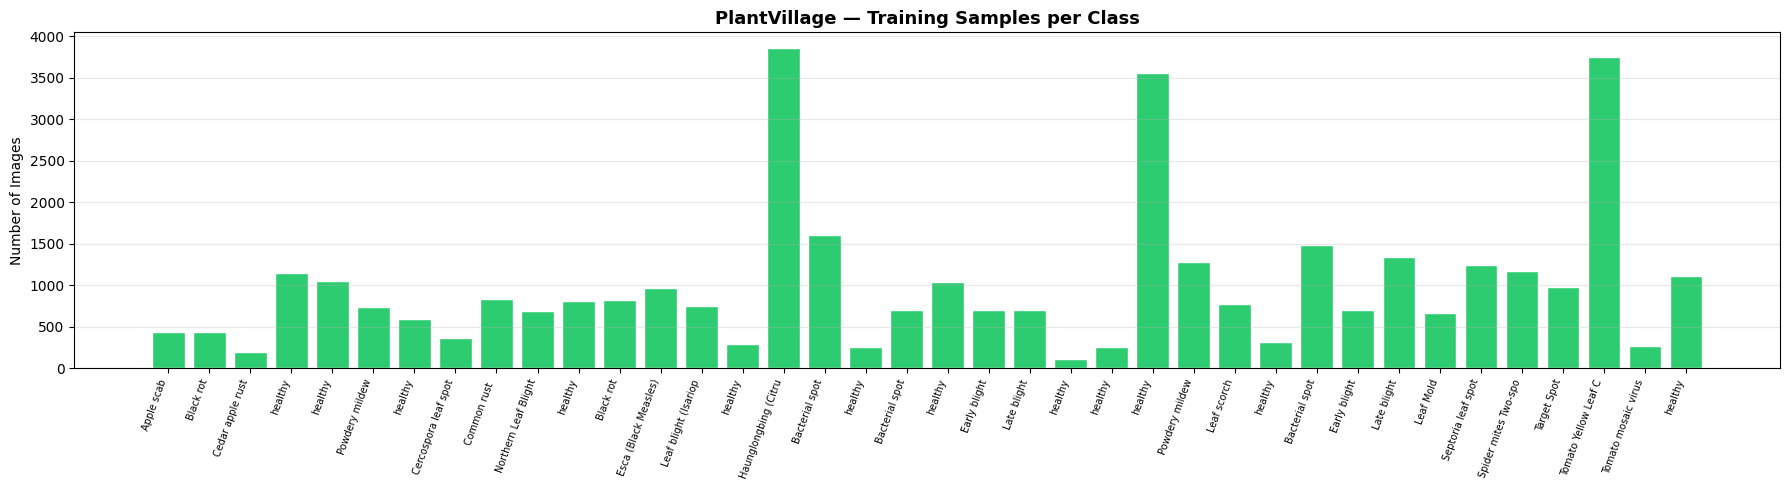

Total training samples  : 38029
Total validation samples: 16276


In [11]:
from collections import Counter

class_counts  = Counter(train_gen.classes)
sorted_counts = [class_counts.get(i, 0) for i in range(len(CLASS_NAMES))]
short_names   = [n.split("___")[-1].replace("_", " ")[:20] for n in CLASS_NAMES]

fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(range(len(CLASS_NAMES)), sorted_counts, color="#2ecc71", edgecolor="white")
ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(short_names, rotation=70, ha="right", fontsize=7)
ax.set_title("PlantVillage — Training Samples per Class", fontsize=13, fontweight="bold")
ax.set_ylabel("Number of Images")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / "class_distribution.png"), dpi=120, bbox_inches="tight")
plt.show()
print(f"Total training samples  : {train_gen.n}")
print(f"Total validation samples: {val_gen.n}")
train_gen.reset()
val_gen.reset()


## 6. Build Models

Both models use `include_preprocessing=False` because we already apply
`efficientnet.preprocess_input` in the data pipeline. Without this flag,
preprocessing would be applied twice causing incorrect input values.


In [12]:
def build_cnn_classifier(num_classes: int, config: dict):
    base_model = EfficientNetB0(
        weights="imagenet",
        include_top=False,
        input_shape=(config["img_size"][0], config["img_size"][1], 3),
    )
    base_model.trainable = False

    inputs  = base_model.input
    x       = base_model.output
    x       = GlobalAveragePooling2D(name="gap")(x)
    x       = BatchNormalization()(x)
    x       = Dense(256, activation="relu", name="dense_head")(x)
    x       = Dropout(0.4)(x)
    outputs = Dense(num_classes, activation="softmax", name="predictions")(x)

    model = Model(inputs, outputs, name="SmartLeaf_EfficientNetB0")
    model.compile(
        optimizer=Adam(learning_rate=config["learning_rate"]),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model, base_model


def build_feature_extractor(config: dict):
    base_model = EfficientNetB0(
        weights="imagenet",
        include_top=False,
        input_shape=(config["img_size"][0], config["img_size"][1], 3),
    )
    base_model.trainable = False

    inputs    = base_model.input
    x         = GlobalAveragePooling2D(name="feature_pool")(base_model.output)
    extractor = Model(inputs, x, name="EfficientNetB0_Extractor")
    return extractor


NUM_CLASSES = len(CLASS_NAMES)
print(f"Number of classes: {NUM_CLASSES}")

test_cnn, _ = build_cnn_classifier(NUM_CLASSES, CONFIG)
print(f"CNN total params    : {test_cnn.count_params():,}")
print(f"CNN trainable params: {sum(tf.size(w).numpy() for w in test_cnn.trainable_weights):,}")

test_ext = build_feature_extractor(CONFIG)
print(f"Extractor output    : {test_ext.output_shape}")

del test_cnn, test_ext
print("\nModel definitions ready.")

Number of classes: 38
CNN total params    : 4,392,393
CNN trainable params: 340,262
Extractor output    : (None, 1280)

Model definitions ready.


## 7. Feature Extraction (Approach 1)

Runs all images through frozen EfficientNet to get 1280-dim feature vectors.

In [ ]:
def extract_features(extractor, data_gen, num_batches: int = None):
    all_features, all_labels = [], []
    n_batches = num_batches or len(data_gen)

    for i, (batch_x, batch_y) in enumerate(data_gen):
        if i >= n_batches:
            break
        feats = extractor.predict(batch_x, verbose=0)
        all_features.append(feats)
        all_labels.append(np.argmax(batch_y, axis=1))
        if (i + 1) % 50 == 0:
            print(f"  Batch {i+1:4d} / {n_batches}")

    features = np.vstack(all_features)
    labels   = np.concatenate(all_labels)
    return features, labels


if TRAIN_SVM:
    print("Building feature extractor...")
    extractor = build_feature_extractor(CONFIG)

    print(f"\nExtracting TRAINING features ({train_gen.n} images)...")
    train_gen.reset()
    t0 = time.time()
    X_train, y_train = extract_features(extractor, train_gen, len(train_gen))

    print(f"\nExtracting VALIDATION features ({val_gen.n} images)...")
    val_gen.reset()
    X_val, y_val = extract_features(extractor, val_gen, len(val_gen))

    feature_time = time.time() - t0
    print(f"\nFeature extraction complete in {feature_time:.1f}s")
    print(f"  X_train : {X_train.shape}")
    print(f"  X_val   : {X_val.shape}")

    scaler     = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_val_sc   = scaler.transform(X_val)
    print("  Features standardised.")

    train_gen.reset()
    val_gen.reset()
else:
    print("TRAIN_SVM=False — skipping feature extraction.")


Building feature extractor...

Extracting TRAINING features (38029 images)...
  Batch   50 / 2377
  Batch  100 / 2377
  Batch  150 / 2377
  Batch  200 / 2377
  Batch  250 / 2377
  Batch  300 / 2377
  Batch  350 / 2377
  Batch  400 / 2377
  Batch  450 / 2377
  Batch  500 / 2377
  Batch  550 / 2377
  Batch  600 / 2377
  Batch  650 / 2377
  Batch  700 / 2377
  Batch  750 / 2377
  Batch  800 / 2377
  Batch  850 / 2377
  Batch  900 / 2377
  Batch  950 / 2377
  Batch 1000 / 2377
  Batch 1050 / 2377
  Batch 1100 / 2377
  Batch 1150 / 2377
  Batch 1200 / 2377
  Batch 1250 / 2377
  Batch 1300 / 2377
  Batch 1350 / 2377
  Batch 1400 / 2377
  Batch 1450 / 2377
  Batch 1500 / 2377
  Batch 1550 / 2377
  Batch 1600 / 2377
  Batch 1650 / 2377
  Batch 1700 / 2377
  Batch 1750 / 2377
  Batch 1800 / 2377
  Batch 1850 / 2377
  Batch 1900 / 2377
  Batch 1950 / 2377
  Batch 2000 / 2377
  Batch 2050 / 2377
  Batch 2100 / 2377
  Batch 2150 / 2377
  Batch 2200 / 2377
  Batch 2250 / 2377
  Batch 2300 / 2377
  

## 8. Train Approach 1 — SVM Classifier

Single `.fit()` call on 1280-dim feature vectors. Runs on CPU. Takes ~30–50 min without `max_iter`, or ~10–15 min with `max_iter=1000`.

In [ ]:
svm_result = None

if TRAIN_SVM:

    svm = SVC(
        C=CONFIG["svm_C"],
        kernel=CONFIG["svm_kernel"],
        probability=True,
        random_state=CONFIG["random_seed"],
        verbose=True,
        max_iter=1000,   
    )

    t0 = time.time()
    svm.fit(X_train_sc, y_train)
    svm_train_time = time.time() - t0
    print(f"\nSVM training complete in {svm_train_time:.1f}s")

    y_pred_svm = svm.predict(X_val_sc)
    svm_acc    = accuracy_score(y_val, y_pred_svm)
    svm_cm     = confusion_matrix(y_val, y_pred_svm)

    print(f"\nSVM Validation Results:")
    print(f"  Accuracy  : {svm_acc:.4f}  ({svm_acc*100:.2f}%)")
    print(f"  Precision : {precision_score(y_val, y_pred_svm, average='weighted', zero_division=0):.4f}")
    print(f"  Recall    : {recall_score(y_val, y_pred_svm, average='weighted', zero_division=0):.4f}")
    print(f"  F1-Score  : {f1_score(y_val, y_pred_svm, average='weighted', zero_division=0):.4f}")

    with open(MODELS_DIR / "svm_classifier.pkl", "wb") as f:
        pickle.dump(svm, f)
    with open(MODELS_DIR / "feature_scaler.pkl", "wb") as f:
        pickle.dump(scaler, f)
    print(f"\nSVM saved    -> {MODELS_DIR / 'svm_classifier.pkl'}")
    print(f"Scaler saved -> {MODELS_DIR / 'feature_scaler.pkl'}")

    svm_result = {
        "approach":         "CNN Feature Extractor + SVM",
        "accuracy":         float(svm_acc),
        "precision":        float(precision_score(y_val, y_pred_svm, average="weighted", zero_division=0)),
        "recall":           float(recall_score(y_val, y_pred_svm, average="weighted", zero_division=0)),
        "f1_score":         float(f1_score(y_val, y_pred_svm, average="weighted", zero_division=0)),
        "confusion_matrix": svm_cm.tolist(),
        "training_time_s":  round(svm_train_time + feature_time, 1),
        "predictions":      y_pred_svm,
        "true_labels":      y_val,
    }
else:
    print("TRAIN_SVM=False — skipping SVM training.")


  APPROACH 1: Training SVM
  C=10, kernel=rbf
[LibSVM]
SVM training complete in 2082.6s

SVM Validation Results:
  Accuracy  : 0.9763  (97.63%)
  Precision : 0.9763
  Recall    : 0.9763
  F1-Score  : 0.9762

SVM saved    -> C:\Users\moham\OneDrive\Desktop\Studying\Deep Learning Project\SmartLeaf-AI\models\svm_classifier.pkl
Scaler saved -> C:\Users\moham\OneDrive\Desktop\Studying\Deep Learning Project\SmartLeaf-AI\models\feature_scaler.pkl


## 9. Train Approach 2 — CNN Fine-tuning

Two-phase training:
- **Phase 1 (10 epochs):** Only the classification head trains. EfficientNet is fully frozen.
- **Phase 2 (15 epochs):** Top 20 EfficientNet layers unfrozen and fine-tuned at very low LR.

GPU is used automatically. Expected ~60–80 min on GTX 1650.


In [15]:
cnn_result = None

if TRAIN_CNN:
    print("=" * 55)
    print("  APPROACH 2: End-to-End CNN Fine-tuning")
    print("=" * 55)

    NUM_CLASSES = len(CLASS_NAMES)
    cnn_model, base_model = build_cnn_classifier(NUM_CLASSES, CONFIG)

    callbacks = [
        EarlyStopping(
            monitor="val_accuracy", patience=5,
            restore_best_weights=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss", factor=0.5,
            patience=3, min_lr=1e-7, verbose=1
        ),
        ModelCheckpoint(
            str(MODELS_DIR / "efficientnet_best.h5"),
            monitor="val_accuracy",
            save_best_only=True, verbose=1,
            save_weights_only=True,    # avoids TF 2.10 JSON serialization bug
        ),
    ]

    # ── Phase 1: Train classification head, base frozen ──────────────────────
    print(f"\nPhase 1: Training head ({CONFIG['epochs_frozen']} epochs, base frozen)...")
    train_gen.reset()
    val_gen.reset()
    t0 = time.time()
    history1 = cnn_model.fit(
        train_gen,
        epochs=CONFIG["epochs_frozen"],
        validation_data=val_gen,
        callbacks=callbacks,
        verbose=1,
    )
    phase1_time = time.time() - t0
    print(f"Phase 1 complete in {phase1_time:.1f}s")

    # ── Phase 2: Unfreeze top layers and fine-tune ────────────────────────────
    print(f"\nPhase 2: Fine-tuning top {CONFIG['num_unfreeze_layers']} layers...")
    base_model.trainable = True
    n_layers = len(base_model.layers)
    for layer in base_model.layers[: n_layers - CONFIG["num_unfreeze_layers"]]:
        layer.trainable = False

    trainable_count = sum(1 for l in base_model.layers if l.trainable)
    print(f"  Trainable base layers: {trainable_count} / {n_layers}")

    cnn_model.compile(
        optimizer=Adam(learning_rate=CONFIG["finetune_lr"]),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    train_gen.reset()
    val_gen.reset()
    history2 = cnn_model.fit(
        train_gen,
        epochs=CONFIG["epochs_finetune"],
        validation_data=val_gen,
        callbacks=callbacks,
        verbose=1,
    )
    total_cnn_time = time.time() - t0
    print(f"\nPhase 2 complete. Total CNN training time: {total_cnn_time:.1f}s")

    # ── Merge histories ───────────────────────────────────────────────────────
    combined_history = {
        "accuracy":     history1.history["accuracy"]     + history2.history["accuracy"],
        "val_accuracy": history1.history["val_accuracy"] + history2.history["val_accuracy"],
        "loss":         history1.history["loss"]         + history2.history["loss"],
        "val_loss":     history1.history["val_loss"]     + history2.history["val_loss"],
    }

    # ── Evaluate ──────────────────────────────────────────────────────────────
    val_gen.reset()
    y_pred_probs = cnn_model.predict(val_gen, verbose=1)
    y_pred_cnn   = np.argmax(y_pred_probs, axis=1)
    y_true_cnn   = val_gen.classes[: len(y_pred_cnn)]

    cnn_acc = accuracy_score(y_true_cnn, y_pred_cnn)
    cnn_cm  = confusion_matrix(y_true_cnn, y_pred_cnn)

    print(f"\nCNN Validation Results:")
    print(f"  Accuracy  : {cnn_acc:.4f}  ({cnn_acc*100:.2f}%)")
    print(f"  Precision : {precision_score(y_true_cnn, y_pred_cnn, average='weighted', zero_division=0):.4f}")
    print(f"  Recall    : {recall_score(y_true_cnn, y_pred_cnn, average='weighted', zero_division=0):.4f}")
    print(f"  F1-Score  : {f1_score(y_true_cnn, y_pred_cnn, average='weighted', zero_division=0):.4f}")

    cnn_model.save(str(MODELS_DIR / "efficientnet_finetuned.h5"))
    print(f"\nCNN model saved -> {MODELS_DIR / 'efficientnet_finetuned.h5'}")

    cnn_result = {
        "approach":         "End-to-End CNN (EfficientNet-B0 Fine-tuned)",
        "accuracy":         float(cnn_acc),
        "precision":        float(precision_score(y_true_cnn, y_pred_cnn, average="weighted", zero_division=0)),
        "recall":           float(recall_score(y_true_cnn, y_pred_cnn, average="weighted", zero_division=0)),
        "f1_score":         float(f1_score(y_true_cnn, y_pred_cnn, average="weighted", zero_division=0)),
        "confusion_matrix": cnn_cm.tolist(),
        "training_time_s":  round(total_cnn_time, 1),
        "history":          combined_history,
        "predictions":      y_pred_cnn,
        "true_labels":      y_true_cnn,
    }
else:
    print("TRAIN_CNN=False — skipping CNN training.")


  APPROACH 2: End-to-End CNN Fine-tuning

Phase 1: Training head (10 epochs, base frozen)...
Epoch 1/10
2377/2377 [==============================] - ETA: 0s - loss: 0.5487 - accuracy: 0.8399
Epoch 1: val_accuracy improved from -inf to 0.95453, saving model to C:\Users\moham\OneDrive\Desktop\Studying\Deep Learning Project\SmartLeaf-AI\models\efficientnet_best.h5
2377/2377 [==============================] - 671s 279ms/step - loss: 0.5487 - accuracy: 0.8399 - val_loss: 0.1460 - val_accuracy: 0.9545 - lr: 0.0010
Epoch 2/10
2377/2377 [==============================] - ETA: 0s - loss: 0.3249 - accuracy: 0.9010
Epoch 2: val_accuracy did not improve from 0.95453
2377/2377 [==============================] - 658s 277ms/step - loss: 0.3249 - accuracy: 0.9010 - val_loss: 0.1428 - val_accuracy: 0.9540 - lr: 0.0010
Epoch 3/10
2377/2377 [==============================] - ETA: 0s - loss: 0.2910 - accuracy: 0.9115
Epoch 3: val_accuracy improved from 0.95453 to 0.95718, saving model to C:\Users\moham\On

TypeError: Unable to serialize [2.0896919 2.1128857 2.1081853] to JSON. Unrecognized type <class 'tensorflow.python.framework.ops.EagerTensor'>.

In [16]:
# Save model weights only — bypasses TF 2.10 JSON serialization bug
cnn_model.save_weights(str(MODELS_DIR / "efficientnet_finetuned.h5"))
print(f"CNN weights saved -> {MODELS_DIR / 'efficientnet_finetuned.h5'}")

# Continue with cnn_result
cnn_acc = accuracy_score(y_true_cnn, y_pred_cnn)
cnn_cm  = confusion_matrix(y_true_cnn, y_pred_cnn)

cnn_result = {
    "approach":         "End-to-End CNN (EfficientNet-B0 Fine-tuned)",
    "accuracy":         float(cnn_acc),
    "precision":        float(precision_score(y_true_cnn, y_pred_cnn, average="weighted", zero_division=0)),
    "recall":           float(recall_score(y_true_cnn, y_pred_cnn, average="weighted", zero_division=0)),
    "f1_score":         float(f1_score(y_true_cnn, y_pred_cnn, average="weighted", zero_division=0)),
    "confusion_matrix": cnn_cm.tolist(),
    "training_time_s":  round(total_cnn_time, 1),
    "history":          combined_history,
    "predictions":      y_pred_cnn,
    "true_labels":      y_true_cnn,
}

print(f"\nCNN Validation Results:")
print(f"  Accuracy  : {cnn_acc:.4f}  ({cnn_acc*100:.2f}%)")
print(f"  Precision : {precision_score(y_true_cnn, y_pred_cnn, average='weighted', zero_division=0):.4f}")
print(f"  Recall    : {recall_score(y_true_cnn, y_pred_cnn, average='weighted', zero_division=0):.4f}")
print(f"  F1-Score  : {f1_score(y_true_cnn, y_pred_cnn, average='weighted', zero_division=0):.4f}")

CNN weights saved -> C:\Users\moham\OneDrive\Desktop\Studying\Deep Learning Project\SmartLeaf-AI\models\efficientnet_finetuned.h5

CNN Validation Results:
  Accuracy  : 0.9867  (98.67%)
  Precision : 0.9867
  Recall    : 0.9867
  F1-Score  : 0.9867


## 10. Evaluate & Compare Both Models

In [17]:
if cnn_result and svm_result:
    print("=" * 60)
    print("  MODEL COMPARISON")
    print("=" * 60)
    metrics = ["accuracy", "precision", "recall", "f1_score"]
    print(f"  {'Metric':<15} {'CNN':>12} {'SVM':>12} {'Winner':>10}")
    print("  " + "-" * 50)
    for m in metrics:
        c, s  = cnn_result[m], svm_result[m]
        winner = "CNN" if c >= s else "SVM"
        print(f"  {m:<15} {c:>12.4f} {s:>12.4f} {winner:>10}")
    print("  " + "-" * 50)
    print(f"  {'Train time':<15} {cnn_result['training_time_s']:>11.1f}s {svm_result['training_time_s']:>11.1f}s")
    overall = "CNN" if cnn_result["accuracy"] > svm_result["accuracy"] else "SVM"
    print(f"\n  Overall winner: {overall}")
elif cnn_result:
    print(f"CNN only — Accuracy: {cnn_result['accuracy']:.4f}")
elif svm_result:
    print(f"SVM only — Accuracy: {svm_result['accuracy']:.4f}")
else:
    print("No results yet.")


  MODEL COMPARISON
  Metric                   CNN          SVM     Winner
  --------------------------------------------------
  accuracy              0.9867       0.9763        CNN
  precision             0.9867       0.9763        CNN
  recall                0.9867       0.9763        CNN
  f1_score              0.9867       0.9762        CNN
  --------------------------------------------------
  Train time          14449.2s      3092.2s

  Overall winner: CNN


## 11. Visualizations

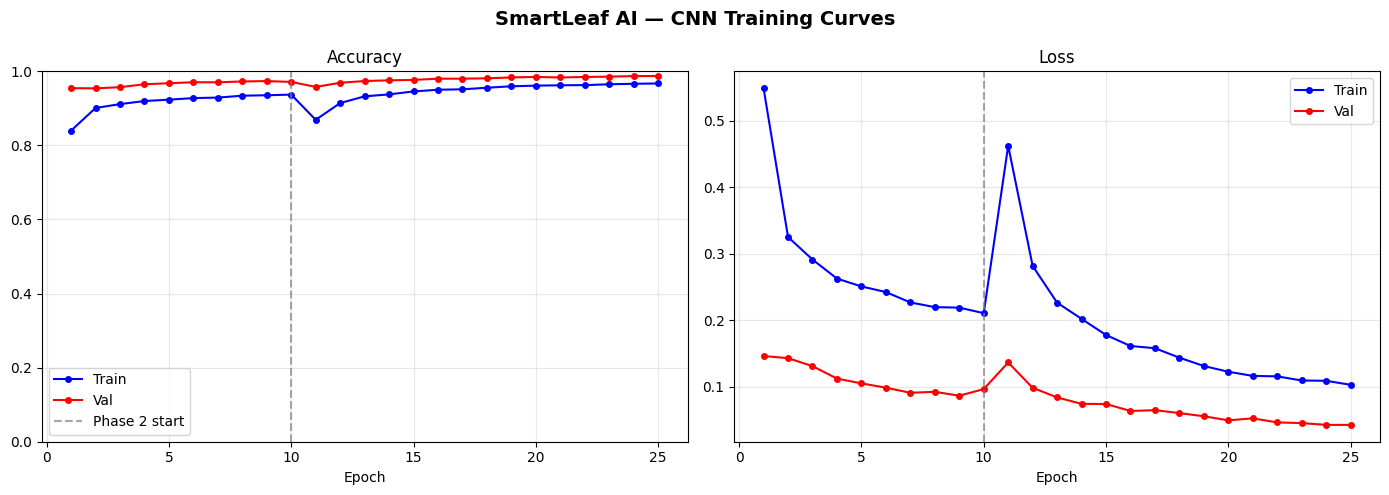

Saved -> results/training_curves.png


In [18]:
# CNN Learning Curves
if cnn_result and "history" in cnn_result:
    history = cnn_result["history"]
    epochs  = range(1, len(history["accuracy"]) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("SmartLeaf AI — CNN Training Curves", fontsize=14, fontweight="bold")

    ax1.plot(epochs, history["accuracy"],     "b-o", label="Train", markersize=4)
    ax1.plot(epochs, history["val_accuracy"], "r-o", label="Val",   markersize=4)
    ax1.axvline(x=CONFIG["epochs_frozen"], color="gray", linestyle="--",
                alpha=0.7, label=f"Phase 2 start")
    ax1.set_title("Accuracy"); ax1.set_xlabel("Epoch"); ax1.set_ylim([0, 1])
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, history["loss"],     "b-o", label="Train", markersize=4)
    ax2.plot(epochs, history["val_loss"], "r-o", label="Val",   markersize=4)
    ax2.axvline(x=CONFIG["epochs_frozen"], color="gray", linestyle="--", alpha=0.7)
    ax2.set_title("Loss"); ax2.set_xlabel("Epoch")
    ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(str(RESULTS_DIR / "training_curves.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved -> results/training_curves.png")


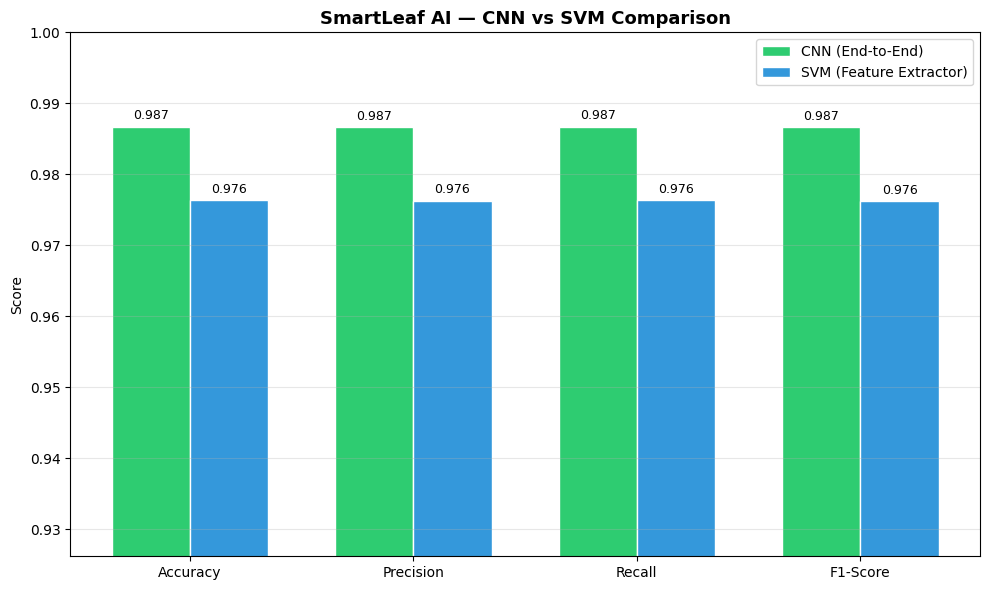

Saved -> results/model_comparison.png


In [19]:
# CNN vs SVM comparison bar chart
if cnn_result and svm_result:
    metrics       = ["accuracy", "precision", "recall", "f1_score"]
    metric_labels = ["Accuracy", "Precision", "Recall", "F1-Score"]
    cnn_vals      = [cnn_result[m] for m in metrics]
    svm_vals      = [svm_result[m] for m in metrics]

    x, width = np.arange(len(metric_labels)), 0.35
    fig, ax = plt.subplots(figsize=(10, 6))
    bars1 = ax.bar(x - width/2, cnn_vals, width, label="CNN (End-to-End)",        color="#2ecc71", edgecolor="white")
    bars2 = ax.bar(x + width/2, svm_vals, width, label="SVM (Feature Extractor)", color="#3498db", edgecolor="white")

    ax.set_title("SmartLeaf AI — CNN vs SVM Comparison", fontsize=13, fontweight="bold")
    ax.set_ylabel("Score"); ax.set_xticks(x); ax.set_xticklabels(metric_labels)
    ax.set_ylim([max(0.6, min(cnn_vals + svm_vals) - 0.05), 1.0])
    ax.legend(); ax.grid(True, axis="y", alpha=0.3)

    for bar in list(bars1) + list(bars2):
        ax.annotate(f"{bar.get_height():.3f}",
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.savefig(str(RESULTS_DIR / "model_comparison.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved -> results/model_comparison.png")


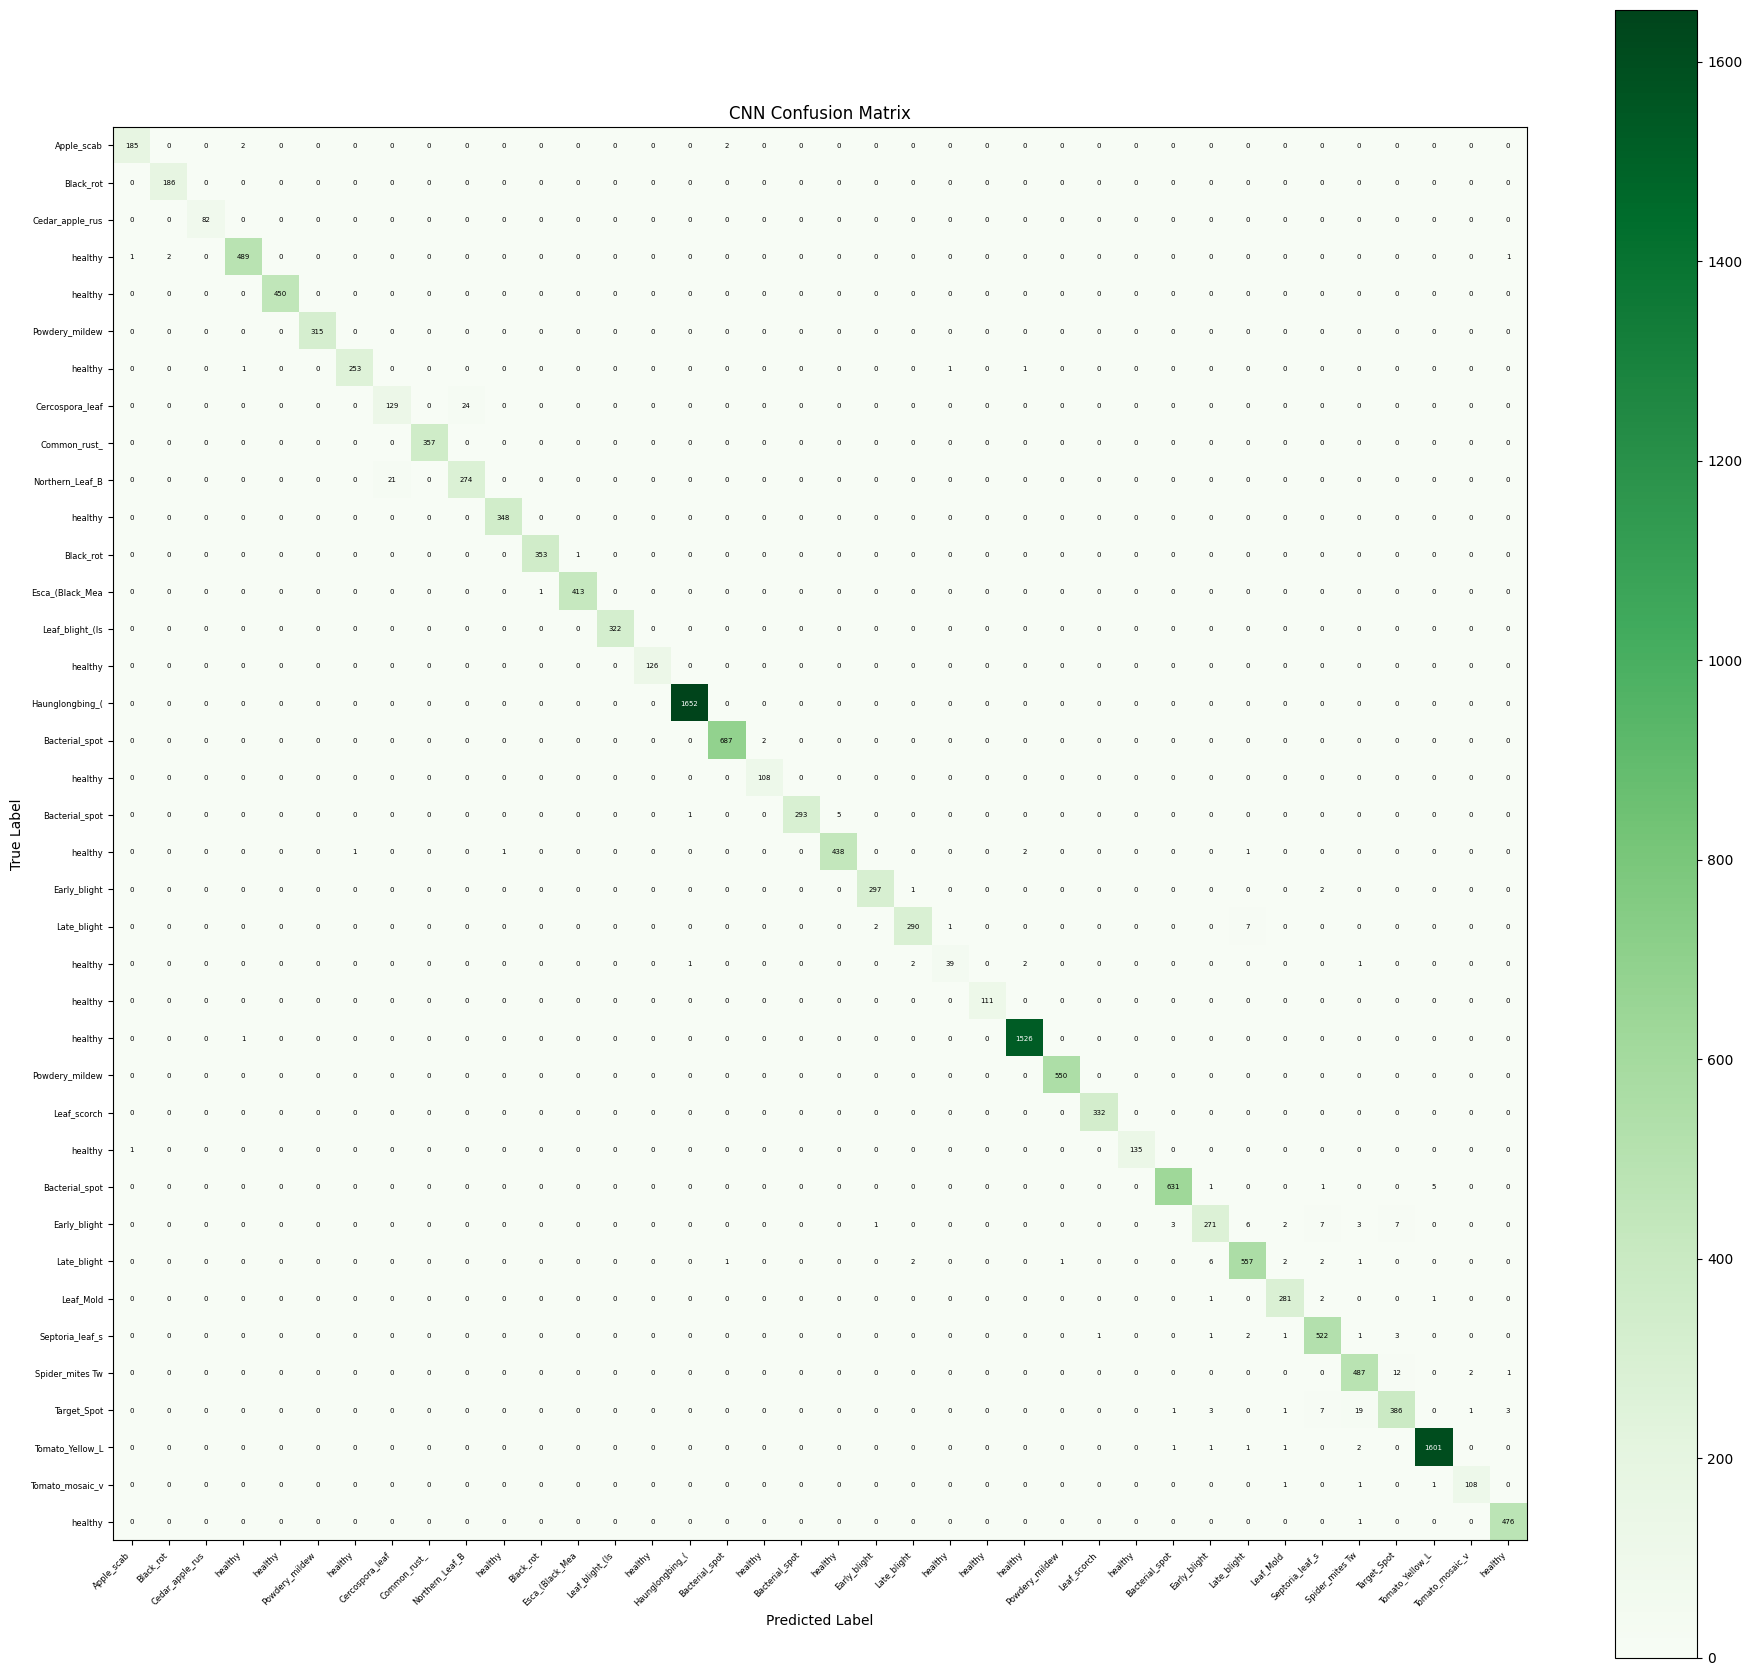

Saved -> C:\Users\moham\OneDrive\Desktop\Studying\Deep Learning Project\SmartLeaf-AI\results\confusion_matrix_cnn.png


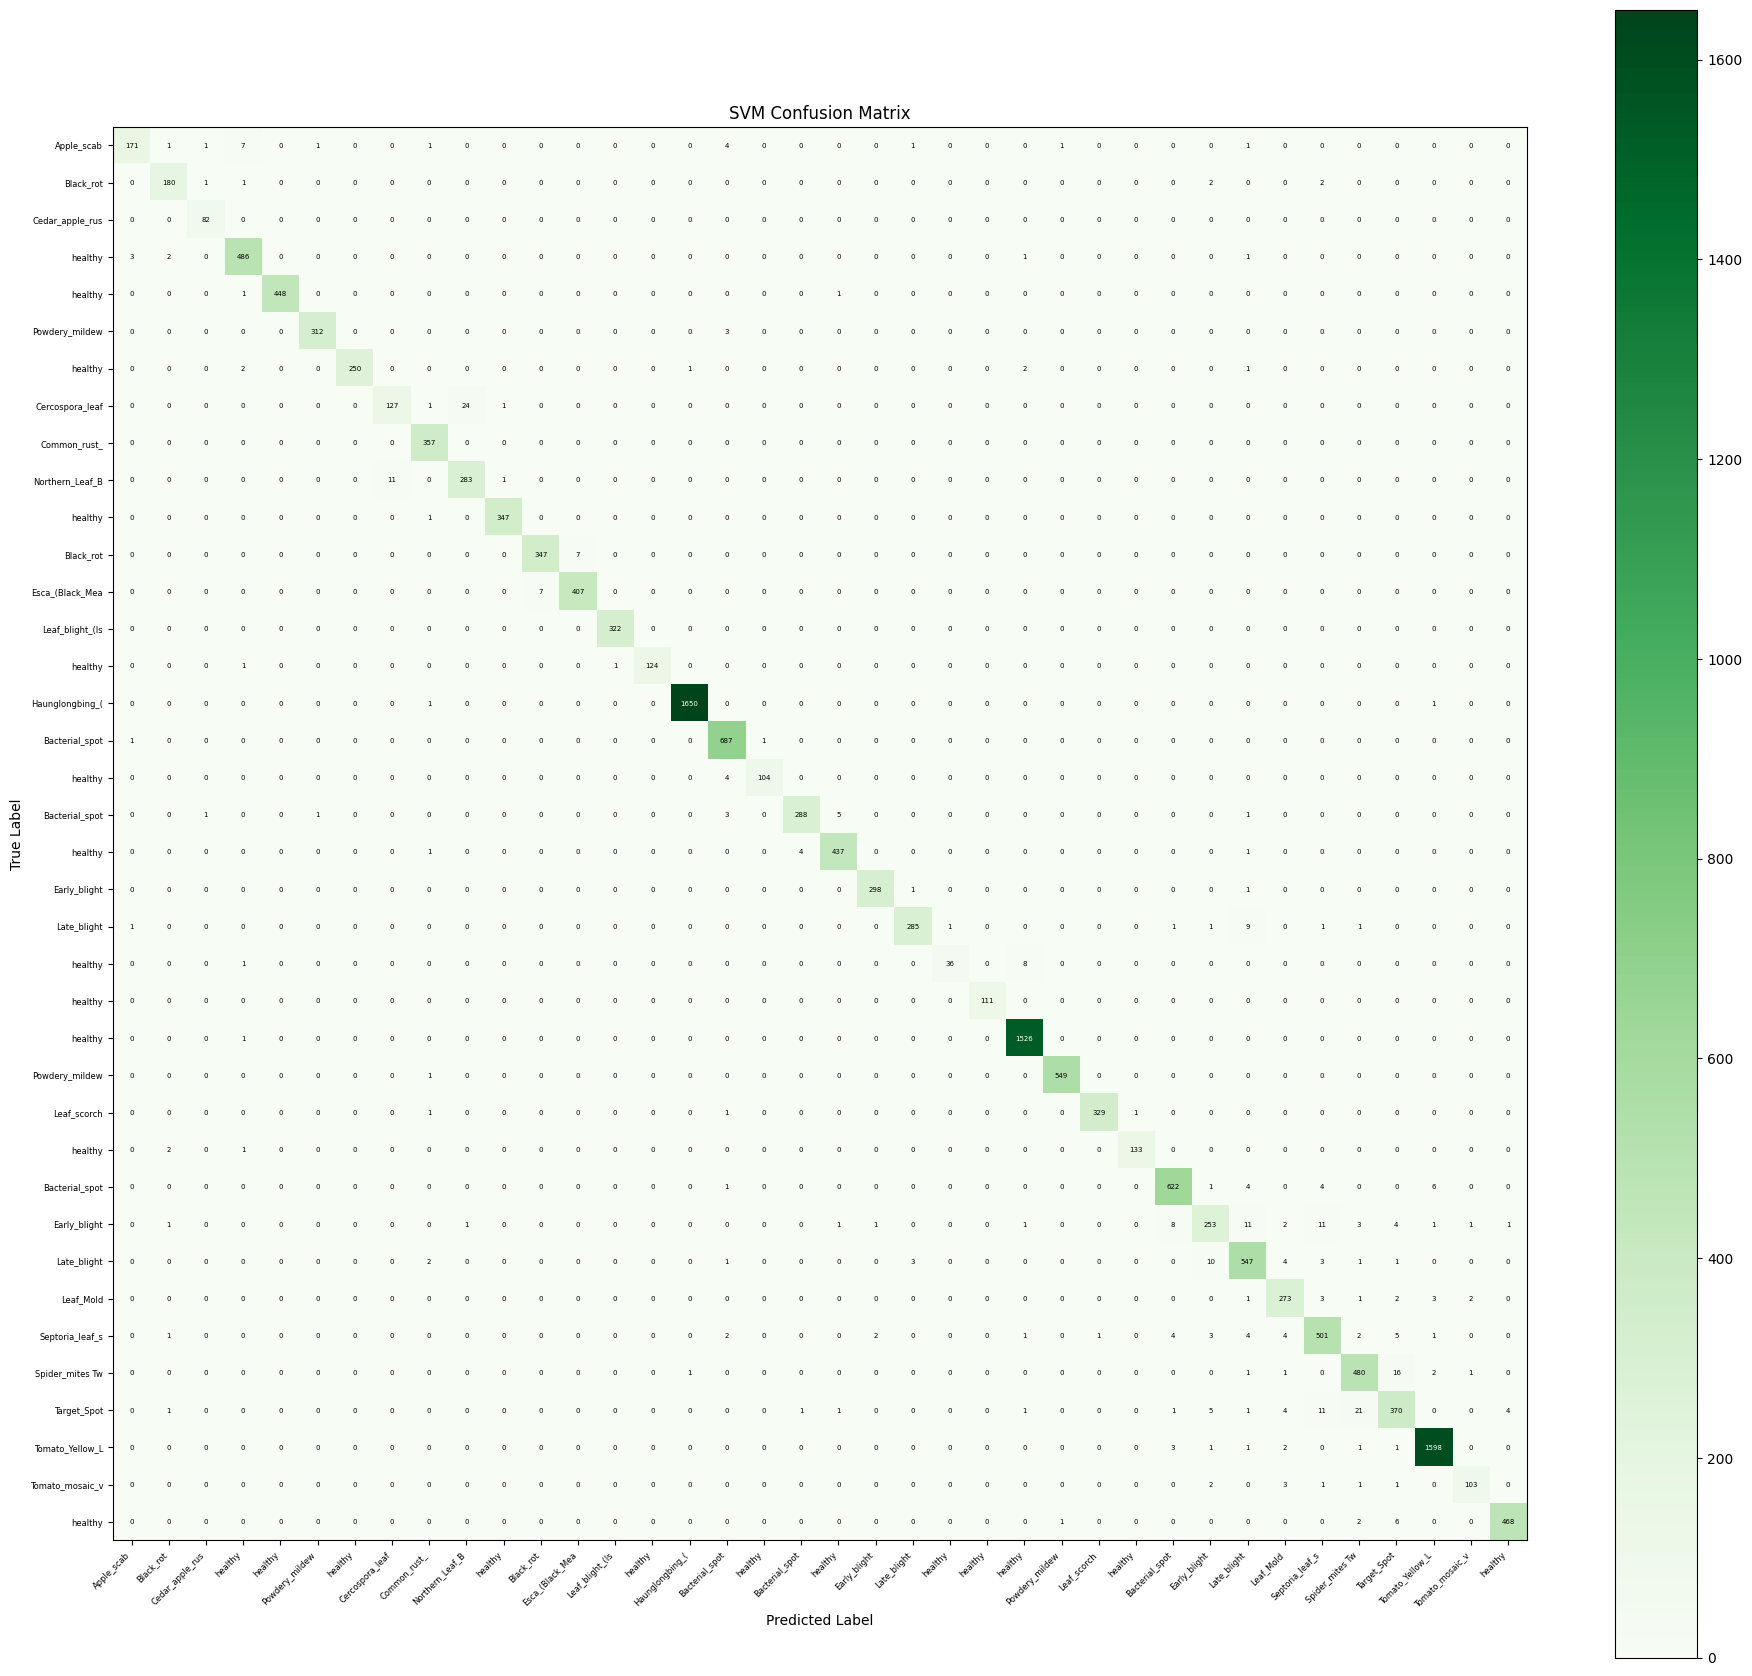

Saved -> C:\Users\moham\OneDrive\Desktop\Studying\Deep Learning Project\SmartLeaf-AI\results\confusion_matrix_svm.png


In [20]:
# Confusion matrices
def plot_cm(cm, class_names, title, output_path):
    short    = [n.split("___")[-1][:15] for n in class_names]
    fig_size = max(10, len(class_names) // 2)
    fig, ax  = plt.subplots(figsize=(fig_size, fig_size - 2))
    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Greens)
    plt.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(len(class_names)), yticks=np.arange(len(class_names)),
           xticklabels=short, yticklabels=short, title=title,
           ylabel="True Label", xlabel="Predicted Label")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=6)
    plt.setp(ax.get_yticklabels(), fontsize=6)
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], "d"), ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black", fontsize=5)
    plt.tight_layout()
    plt.savefig(str(output_path), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {output_path}")

if cnn_result:
    plot_cm(np.array(cnn_result["confusion_matrix"]), CLASS_NAMES,
            "CNN Confusion Matrix", RESULTS_DIR / "confusion_matrix_cnn.png")
if svm_result:
    plot_cm(np.array(svm_result["confusion_matrix"]), CLASS_NAMES,
            "SVM Confusion Matrix", RESULTS_DIR / "confusion_matrix_svm.png")


## 12. Save Results

Saves `comparison_results.json` and `class_labels.json` for the Flask backend.

In [21]:
def save_results(cnn_res, svm_res, class_names):
    results = {
        "generated_at": datetime.now().isoformat(),
        "num_classes":  len(class_names),
        "class_names":  class_names,
    }
    if cnn_res:
        results["cnn"] = {
            "name":                  cnn_res["approach"],
            "accuracy":              round(cnn_res["accuracy"]  * 100, 2),
            "precision":             round(cnn_res["precision"] * 100, 2),
            "recall":                round(cnn_res["recall"]    * 100, 2),
            "f1_score":              round(cnn_res["f1_score"]  * 100, 2),
            "training_time_seconds": cnn_res["training_time_s"],
        }
    if svm_res:
        results["svm"] = {
            "name":                  svm_res["approach"],
            "accuracy":              round(svm_res["accuracy"]  * 100, 2),
            "precision":             round(svm_res["precision"] * 100, 2),
            "recall":                round(svm_res["recall"]    * 100, 2),
            "f1_score":              round(svm_res["f1_score"]  * 100, 2),
            "training_time_seconds": svm_res["training_time_s"],
        }
    if cnn_res and svm_res:
        winner = "CNN" if cnn_res["accuracy"] > svm_res["accuracy"] else "SVM"
        results["winner"]  = winner
        results["summary"] = (
            f"End-to-End CNN achieved {cnn_res['accuracy']:.1%} accuracy "
            f"vs SVM {svm_res['accuracy']:.1%}. "
            f"CNN training: {cnn_res['training_time_s']}s, SVM: {svm_res['training_time_s']}s."
        )

    comp_path = RESULTS_DIR / "comparison_results.json"
    with open(str(comp_path), "w") as f:
        json.dump(results, f, indent=2)
    print(f"comparison_results.json -> {comp_path}")

    labels_path = MODELS_DIR / "class_labels.json"
    with open(str(labels_path), "w") as f:
        json.dump(class_names, f)
    print(f"class_labels.json       -> {labels_path}")


save_results(cnn_result, svm_result, CLASS_NAMES)


comparison_results.json -> C:\Users\moham\OneDrive\Desktop\Studying\Deep Learning Project\SmartLeaf-AI\results\comparison_results.json
class_labels.json       -> C:\Users\moham\OneDrive\Desktop\Studying\Deep Learning Project\SmartLeaf-AI\models\class_labels.json


## 13. Final Summary

In [22]:
print("=" * 60)
print("  SMARTLEAF AI — TRAINING COMPLETE")
print("=" * 60)

for result in [cnn_result, svm_result]:
    if result:
        print(f"\n  {result['approach']}")
        print(f"    Accuracy   : {result['accuracy']:.4f}  ({result['accuracy']*100:.2f}%)")
        print(f"    Precision  : {result['precision']:.4f}")
        print(f"    Recall     : {result['recall']:.4f}")
        print(f"    F1-Score   : {result['f1_score']:.4f}")
        print(f"    Train time : {result['training_time_s']}s")

print()
print(f"  Models  -> {MODELS_DIR}")
print(f"  Results -> {RESULTS_DIR}")
print()
print("  Saved files:")
all_files = (list(MODELS_DIR.glob("*.h5"))  + list(MODELS_DIR.glob("*.pkl")) +
             list(MODELS_DIR.glob("*.json")) + list(RESULTS_DIR.glob("*.json")) +
             list(RESULTS_DIR.glob("*.png")))
for f in sorted(all_files):
    print(f"    {f.name:<45} {f.stat().st_size // 1024:>6} KB")

print()
print("  Next step: start the Flask backend")
print("    cd backend && python app.py")
print("    Open http://localhost:5000")
print("=" * 60)


  SMARTLEAF AI — TRAINING COMPLETE

  End-to-End CNN (EfficientNet-B0 Fine-tuned)
    Accuracy   : 0.9867  (98.67%)
    Precision  : 0.9867
    Recall     : 0.9867
    F1-Score   : 0.9867
    Train time : 14449.2s

  CNN Feature Extractor + SVM
    Accuracy   : 0.9763  (97.63%)
    Precision  : 0.9763
    Recall     : 0.9763
    F1-Score   : 0.9762
    Train time : 3092.2s

  Models  -> C:\Users\moham\OneDrive\Desktop\Studying\Deep Learning Project\SmartLeaf-AI\models
  Results -> C:\Users\moham\OneDrive\Desktop\Studying\Deep Learning Project\SmartLeaf-AI\results

  Saved files:
    class_labels.json                                  1 KB
    efficientnet_best.h5                           17681 KB
    efficientnet_finetuned.h5                      17681 KB
    feature_scaler.pkl                                30 KB
    svm_classifier.pkl                            209684 KB
    class_distribution.png                            73 KB
    comparison_results.json                           